In [28]:
# Import necessary libraries

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
# from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
# ======================================
# Load and Inspect the Dataset
# ======================================

# Load Dataset

df = pd.read_csv("retail_store_inventory.csv")

# Display First 5 Records

print("First 5 Records : ")
print(df.head())

# Display Dataset Shape

print("\nDataset Shape : ")
print(df.shape)

# Display Column Names

print("\nColumn Names : ")
print(df.columns.tolist())

# Display Data Types

print("\nData Types : ")
print(df.dtypes)

First 5 Records : 
         Date     Category Region  Inventory Level  Units Sold  Units Ordered  \
0  01-01-2022    Groceries  North              231         127             55   
1  01-01-2022         Toys  South              204         150             66   
2  01-01-2022         Toys   West              102          65             51   
3  01-01-2022         Toys  North              469          61            164   
4  01-01-2022  Electronics   East              166          14            135   

   Demand Forecast  Price  Discount Weather Condition  Holiday/Promotion  \
0           135.47  33.50        20             Rainy                  0   
1           144.04  63.01        20             Sunny                  0   
2            74.02  27.99        10             Sunny                  1   
3            62.18  32.72        10            Cloudy                  1   
4             9.26  73.64         0             Sunny                  0   

   Competitor Pricing Seasonality  
0

In [31]:
# ======================================
# DATA Preprocessing
# ======================================

# Check Missing Values

print("\nMissing values before preprocessing : ")
print(df.isnull().sum())

# Check Duplicate Records

print("\nNumber of Duplicate records : ", df.duplicated().sum())

# Remove Duplicate Records

df = df.drop_duplicates()

print("\nDataset shape after removing duplicates : ", df.shape)

# Convert Date Column

df["Date"] = pd.to_datetime(
    df["Date"],
    format = "%d-%m-%Y",
    errors = "coerce"
)

print("\nDate column Data type : ")
print(df["Date"].dtypes)


Missing values before preprocessing : 
Date                  0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

Number of Duplicate records :  0

Dataset shape after removing duplicates :  (73100, 13)

Date column Data type : 
datetime64[us]


In [32]:
# ======================================
# Feature Engineering
# ======================================

# Extract Features from Date

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Quarter"] = df["Date"].dt.quarter

# Create Weekend Feature

df["IsWeekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

# Display New Features

print("\nNew features created : ")

print("Year")
print("Month")
print("Day")
print("DayOfWeek")
print("Quarter")
print("IsWeekend")
print("PriceAfterDiscount")

# Display Dataset After Feature Engineering

print("\nDataset after feature engineering : ")
print(df.head())

# Display Shape

print("\nDataset shape after feature engineering : ", df.shape)


New features created : 
Year
Month
Day
DayOfWeek
Quarter
IsWeekend
PriceAfterDiscount

Dataset after feature engineering : 
        Date     Category Region  Inventory Level  Units Sold  Units Ordered  \
0 2022-01-01    Groceries  North              231         127             55   
1 2022-01-01         Toys  South              204         150             66   
2 2022-01-01         Toys   West              102          65             51   
3 2022-01-01         Toys  North              469          61            164   
4 2022-01-01  Electronics   East              166          14            135   

   Demand Forecast  Price  Discount Weather Condition  Holiday/Promotion  \
0           135.47  33.50        20             Rainy                  0   
1           144.04  63.01        20             Sunny                  0   
2            74.02  27.99        10             Sunny                  1   
3            62.18  32.72        10            Cloudy                  1   
4             

In [33]:
# ======================================
# Label Encoding
# ======================================

# Create Label Encoder

label_encoder = LabelEncoder()

# Categorical Columns

categorical_columns = [
    "Category",
    "Region",
    "Weather Condition",
    "Holiday/Promotion",
    "Seasonality"
]

# Apply Label Encoding

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(
        df[column].astype(str)
    )

# Display Encoded Data

print("\nLabel Encoding Completed.")

print("\nEncoded Categorical Columns : ")

print(df[categorical_columns].head())

# Display Data Types

print("\nData types after label encoding : ")
print(df.dtypes)


Label Encoding Completed.

Encoded Categorical Columns : 
   Category  Region  Weather Condition  Holiday/Promotion  Seasonality
0         3       1                  1                  0            0
1         4       2                  3                  0            0
2         4       3                  3                  1            2
3         4       1                  0                  1            0
4         1       0                  3                  0            2

Data types after label encoding : 
Date                  datetime64[us]
Category                       int64
Region                         int64
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Demand Forecast              float64
Price                        float64
Discount                       int64
Weather Condition              int64
Holiday/Promotion              int64
Competitor Pricing           float64
Seasonality                    int6

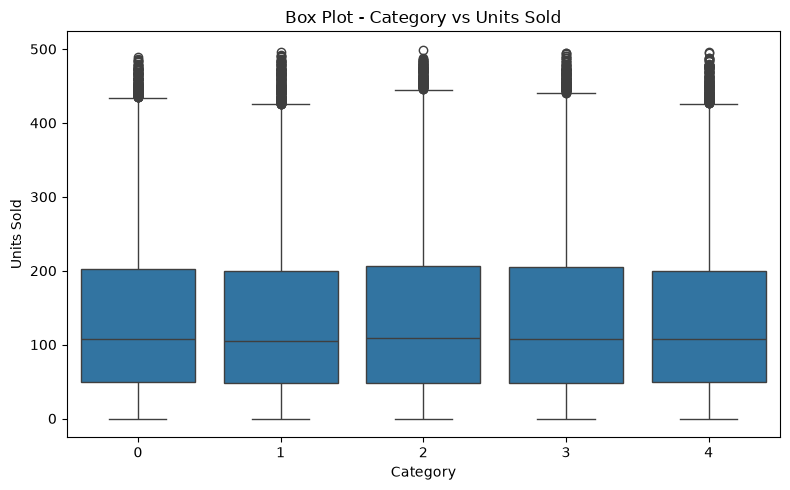

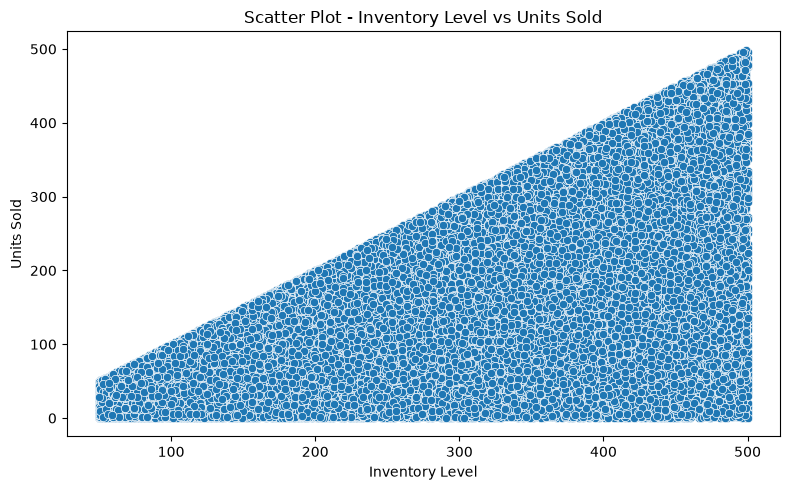

In [ ]:
# ======================================
# Data Visualization
# ======================================

# Box Plot - Category vs Units Sold

plt.figure(figsize=(8,5))

sns.boxplot(
    x = "Category",
    y = "Units Sold",
    data = df
)

plt.title("Box Plot - Category vs Units Sold")
plt.xlabel("Category")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

# Scatter Plot - Inventory Level vs Units Sold

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x = "Inventory Level",
    y = "Units Sold",
    data = df
)

plt.title("Scatter Plot - Inventory Level vs Units Sold")
plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

In [35]:
# ======================================
# Feature Selection and Train/Test Split
# ======================================

# Select Features

features = [
    "Category",
    "Region",
    "Inventory Level",
    "Units Ordered",
    "Demand Forecast",
    "Price",
    "Discount",
    "Weather Condition",
    "Holiday/Promotion",
    "Competitor Pricing",
    "Seasonality",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "Quarter",
    "IsWeekend"
]

# Input Features and Target

x = df[features]
y = df["Units Sold"]

# Display Features and Target

print("\nSelected Features : ", x.columns.tolist())

print("\nTarget Variable : Units Sold")

# Train/Test Split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)

# Display Dataset Sizes

print("\nTraining Records :", len(x_train))

print("\nTesting Records :", len(x_test))

print("\nx_train Shape :", x_train.shape)

print("\nx_test Shape :", x_test.shape)

print("\ny_train Shape :", y_train.shape)

print("\ny_test Shape : ", y_test.shape)


Selected Features :  ['Category', 'Region', 'Inventory Level', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality', 'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'IsWeekend']

Target Variable : Units Sold

Training Records : 58480

Testing Records : 14620

x_train Shape : (58480, 17)

x_test Shape : (14620, 17)

y_train Shape : (58480,)

y_test Shape :  (14620,)


In [36]:
# ======================================
# Linear Regression
# ======================================

# Create Linear Regression Model

linear_model = LinearRegression()

# Train the Model

linear_model.fit(x_train, y_train)

# Make Predictions

linear_pred = linear_model.predict(x_test)

# Evaluate Model

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_pred)

# Display Results

print("\n===========================================")
print("Linear Regression Results")
print("===========================================")

print("Mean Absolute Error : ", linear_mae)
print("Mean Squared Error : ", linear_mse)
print("Root Mean Squared Error : ", linear_rmse)
print("R Squared : ", linear_r2)


Linear Regression Results
Mean Absolute Error :  7.418628817650402
Mean Squared Error :  73.98075689469026
Root Mean Squared Error :  8.60120671154288
R Squared :  0.9937514482186399


In [37]:
# ======================================
# Gradient Boosting Regression
# ======================================

# Create Gradient Boosting Model

gbr = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)

# Train the Model

gbr.fit(x_train, y_train)

# Make Predictions

gbr_pred = gbr.predict(x_test)

# Evaluate Model

gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_mse = mean_squared_error(y_test, gbr_pred)
gbr_rmse = np.sqrt(gbr_mse)
gbr_r2 = r2_score(y_test, gbr_pred)

# Display Results

print("\n===========================================")
print("Gradient Boosting Regression Results")
print("===========================================")

print("Mean Absolute Error : ", gbr_mae)
print("Mean Squared Error : ", gbr_mse)
print("Root Mean Squared Error : ", gbr_rmse)
print("R Squared : ", gbr_r2)


Gradient Boosting Regression Results
Mean Absolute Error :  7.288922737575614
Mean Squared Error :  72.61799017479487
Root Mean Squared Error :  8.521618987891612
R Squared :  0.9938665500204139


In [38]:
# ======================================
# Polynomial Regression
# ======================================

# Create Polynomial Features

polynomial_features = PolynomialFeatures(degree = 2, include_bias = False)

# Transform Traing Data

x_train_poly = polynomial_features.fit_transform(x_train)

# Transform Testing Data

x_test_poly = polynomial_features.transform(x_test)

# Create Polynomial Regression Model

polynomial_model = LinearRegression()

# Train the Model

polynomial_model.fit(x_train_poly, y_train)

# Make Predictions

polynomial_pred = polynomial_model.predict(x_test_poly)

# Evaluate Model

polynomial_mae = mean_absolute_error(y_test, polynomial_pred)
polynomial_mse = mean_squared_error(y_test, polynomial_pred)
polynomial_rmse = np.sqrt(polynomial_mse)
polynomial_r2 = r2_score(y_test, polynomial_pred)

# Display Results

print("\n===========================================")
print("Polynomial Regression Results")
print("===========================================")

print("Mean Absolute Error : ", polynomial_mae)
print("Mean Squared Error : ", polynomial_mse)
print("Root Mean Squared Error : ", polynomial_rmse)
print("R Squared : ", polynomial_r2)


Polynomial Regression Results
Mean Absolute Error :  7.372214577854452
Mean Squared Error :  73.2497667711791
Root Mean Squared Error :  8.558607758927797
R Squared :  0.9938131889986772


In [39]:
# ======================================
# Decision Tree Regression
# ======================================

# Create Decision Tree Regression Model

decision_tree_model = DecisionTreeRegressor(max_depth = 10, random_state = 42)

# Train the Model

decision_tree_model.fit(x_train, y_train)

# Make Predictions

decision_tree_pred = decision_tree_model.predict(x_test)

# Evaluate Model

decision_tree_mae = mean_absolute_error(y_test, decision_tree_pred)
decision_tree_mse = mean_squared_error(y_test, decision_tree_pred)
decision_tree_rmse = np.sqrt(decision_tree_mse)
decision_tree_r2 = r2_score(y_test, decision_tree_pred)

# Display Results

print("\n===========================================")
print("Decision Tree Regression Results")
print("===========================================")

print("Mean Absolute Error : ", decision_tree_mae)
print("Mean Squared Error : ", decision_tree_mse)
print("Root Mean Squared Error : ", decision_tree_rmse)
print("R Squared : ", decision_tree_r2)


Decision Tree Regression Results
Mean Absolute Error :  7.3296503537595346
Mean Squared Error :  74.73555778701379
Root Mean Squared Error :  8.644972977807033
R Squared :  0.9936876963369579


In [40]:
# ======================================
# Random Forest Regression
# ======================================

# Create Random Forest Model

rf_model = RandomForestRegressor(n_estimators=50, max_depth=10,random_state=42, n_jobs=-1)

# Train the Model

rf_model.fit(x_train, y_train)

# Make Predictions

rf_pred = rf_model.predict(x_test)

# Evaluate Model

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

# Display Results

print("\n======================================")
print("Random Forest Regression Results")
print("======================================")

print("Mean Absolute Error : ", rf_mae)
print("Mean Squared Error : ", rf_mse)
print("Root Mean Squared Error : ", rf_rmse)
print("R Squared : ", rf_r2)


Random Forest Regression Results
Mean Absolute Error :  7.164671372169614
Mean Squared Error :  70.46604397018449
Root Mean Squared Error :  8.394405516186628
R Squared :  0.9940483073834718


In [41]:
# ======================================
# Model Comparison
# ======================================

# Create Comparison Table

model_comparison = pd.DataFrame({

    "Model" : [
        "Linear Regression",
        "Gradient Boosting Regression",
        "Polynomial Regression",
        "Decision Tree Regression",
        "Random Forest Regression"
    ],

    "MAE" : [
        linear_mae,
        gbr_mae,
        polynomial_mae,
        decision_tree_mae,
        rf_mae
    ],

    "MSE" : [
        linear_mse,
        gbr_mse,
        polynomial_mse,
        decision_tree_mse,
        rf_mse
    ],

    "RMSE" : [
        linear_rmse,
        gbr_rmse,
        polynomial_rmse,
        decision_tree_rmse,
        rf_rmse
    ],

    "R2 SCORE" : [
        linear_r2,
        gbr_r2,
        polynomial_r2,
        decision_tree_r2,
        rf_r2
    ]
})

# Display Model Comparison

print("\n======================================")
print("Model Comparision")
print("======================================")

print(model_comparison.to_string(index = False))

# Find Best Model

best_model_name = model_comparison.loc[
    model_comparison["R2 SCORE"].idxmax(),
    "Model"
]

print("\nBest model based on R2 score : ", best_model_name)


Model Comparision
                       Model      MAE       MSE     RMSE  R2 SCORE
           Linear Regression 7.418629 73.980757 8.601207  0.993751
Gradient Boosting Regression 7.288923 72.617990 8.521619  0.993867
       Polynomial Regression 7.372215 73.249767 8.558608  0.993813
    Decision Tree Regression 7.329650 74.735558 8.644973  0.993688
    Random Forest Regression 7.164671 70.466044 8.394406  0.994048

Best model based on R2 score :  Random Forest Regression
